# GLOBE Curation Quickstart
### Automated Data Cleaning & Master Registry Demo

This notebook demonstrates the core functionality of the GLOBE curation pipeline. It processes 10 years of water transparency data, merges it with historical site metadata, and applies heuristic cleaning to remove common crowdsourcing errors.

### What's happening under the hood?
1. **Local Sync:** Scans your `data/` folder and ensures you have the last 10 years of CSVs.
2. **Relational Build:** Creates a `SQLite` database to link measurements with site history.
3. **Hardware Estimation:** Dynamically estimates Transparency Tube lengths using Maximum Likelihood Estimation (MLE).
4. **Heuristic Curation:** Runs the `disk` and `tube` validators to flag typos and physical impossibilities using dynamic hardware bounds (estimated tube lengths).
5. **Bayesian Inference:** Fits hierarchical PyMC models to generate posterior predictive estimates, accounting for physical right-censoring in tube observations.

### How to use this notebook:
* **Step 1:** Sets up your environment and builds the database.
* **Step 2:** Splits the data into Secchi Disk and Transparency Tube streams.
* **Step 3:** Estimates tube lengths and runs automated outlier detection heuristics.
* **Step 4:** Generates a "Before & After" visualization of the data quality.
* **Step 5:** Runs Bayesian posterior predictive estimation on a subset of data.
* **Step 6:** Visualizes posterior predictive checks showing the natural distribution for Secchi Disk vs. the uncensored distribution for Transparency Tube.


In [1]:
# =============================================================================
# 1. ENVIRONMENT SETUP & NATIVE DATA PIPELINE
# =============================================================================
import datetime
import os

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
import pandas as pd
import seaborn as sns
from IPython.display import display

# Shift the notebook's working directory up to the project root.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

from src.curation.disk_validator import validate_secchi_data
from src.curation.tube_length_estimator import apply_all_tube_estimations
from src.curation.tube_validator import validate_tube_data
from src.curation.distance_to_water import compute_water_distances
from src.database.manager import DatabaseManager
from src.curation.disk_model import BayesianDiskModel
from src.curation.tube_model import BayesianTubeModel
from scipy.stats import lognorm
import numpy as np

# Calculate dynamic 10-year window
current_year = datetime.datetime.now().year
end_year = current_year - 1
start_year = end_year - 9

config = {
    'paths': {
        'observations': 'data/observations/',
        'site_info': 'data/site_info/'
    },
    'distance_to_water': {
        'enabled': True,
        'database': 'data/water_distances.sqlite'
    }
}

demo_db_path = 'data/demo_master_registry.sqlite'
db = DatabaseManager(demo_db_path, overwrite=True)

print(f"Executing pipeline for 10-year observation window: {start_year} - {end_year}")

df_merged = db.load_and_merge_data(config, start_year=start_year, end_year=end_year)

df_merged = compute_water_distances(df_merged, config)

print(f"\n✅ Pipeline execution complete. Successfully processed {len(df_merged)} total observations.")

 -> Wiped existing database at data/demo_master_registry.sqlite
Executing pipeline for 10-year observation window: 2016 - 2025
 -> Synchronizing local data cache for years 2016-2025...
 -> Loading observations from 10 files...
 -> Generating deterministic sample tracking IDs (usid)...
 -> Normalizing site registry into relational tables...
 -> Executing temporal join across 84634 observations...
  -> Loading pre-computed water distance database (method: combined)...
  -> Water distance enrichment complete: 21299/84634 observations matched (method: combined).

✅ Pipeline execution complete. Successfully processed 84634 total observations.


In [2]:
# =============================================================================
# 2. INSTRUMENT ROUTING & DATA PREVIEW
# =============================================================================

print("Routing temporally-merged data into instrument-specific streams...")

# Create disk and tube measurement databases
df_disk, df_tube = db.split_by_instrument(df_merged)

print(f" -> Secchi Disk records extracted: {len(df_disk):,}")
print(f" -> Transparency Tube records extracted: {len(df_tube):,}")

# Preview the head of the Transparency Tube dataset
display(df_tube[['site_id', 'measured_on', 'tube_image_disappearance_cm', 'version_date']].head())

Routing temporally-merged data into instrument-specific streams...
 -> Secchi Disk records extracted: 13,029
 -> Transparency Tube records extracted: 73,329


,site_id,measured_on,tube_image_disappearance_cm,version_date
1,11334,2016-01-01,100.0,2004-11-15 22:24:35
5,6228,2016-01-01,11.0,2005-03-07 08:25:59
8,32843,2016-01-02,60.0,2013-12-02 06:38:05
9,5203,2016-01-03,120.0,2010-05-20 20:01:02
10,5499,2016-01-03,77.0,2011-11-15 09:44:10


In [3]:
# =============================================================================
# 3. TUBE LENGTH ESTIMATION & HEURISTIC CURATION
# =============================================================================

print("Computing dynamic tube length estimates (MLE & Algorithmic)...")
df_tube_estimated = apply_all_tube_estimations(df_tube.copy())

print("Executing automated heuristic outlier detection pipeline on disk records...")
curated_disk = validate_secchi_data(df_disk.copy(), config)

print("Executing automated heuristic outlier detection pipeline on tube records...")
curated_tube = validate_tube_data(df_tube_estimated, config)

# NOTE: High 'Not Near Water' rejection rates are expected — many GLOBE sites have
# inaccurate registered geo-coordinates, placing them far from the actual waterbody.
# Boolean masking
censored_disk = curated_disk.get('is_censored', pd.Series(False, index=curated_disk.index)).astype(bool)
censored_tube = curated_tube.get('is_censored', pd.Series(False, index=curated_tube.index)).astype(bool)

curated_disk['is_true_error'] = ~curated_disk['passed_heuristics'].astype(bool) & ~censored_disk
curated_tube['is_true_error'] = ~curated_tube['passed_heuristics'].astype(bool) & ~censored_tube

print(f"\n✅ Heuristic filtering complete. Isolated {curated_disk['is_true_error'].sum():,} Disk errors and {curated_tube['is_true_error'].sum():,} Tube errors.")


Computing dynamic tube length estimates (MLE & Algorithmic)...
Executing automated heuristic outlier detection pipeline on disk records...
  -> Rejected 4690 records (excluded from Bayesian model):
     - 1088 Confident No Water (Bare land / Snow + >1000m from known waterbody)
     - 3602 Heuristic Failures (Typos, negatives, depth contradictions)
  -> 4786 Right-Censored samples included in model (as lower bounds)
  -> 8339 total records entering Bayesian model
Executing automated heuristic outlier detection pipeline on tube records...
  -> Rejected 21860 records (excluded from Bayesian model):
     - 19126 Confident No Water (Bare land / Snow + >1000m from known waterbody)
     - 2734 Heuristic Failures (Typos, bounds, contradictions)
  -> 40028 Right-Censored samples included in model (as lower bounds)
  -> 51469 total records entering Bayesian model

✅ Heuristic filtering complete. Isolated 4,690 Disk errors and 21,860 Tube errors.



✅ Quickstart plot saved to: output/figures/00_quickstart_demo/kde_plot.png



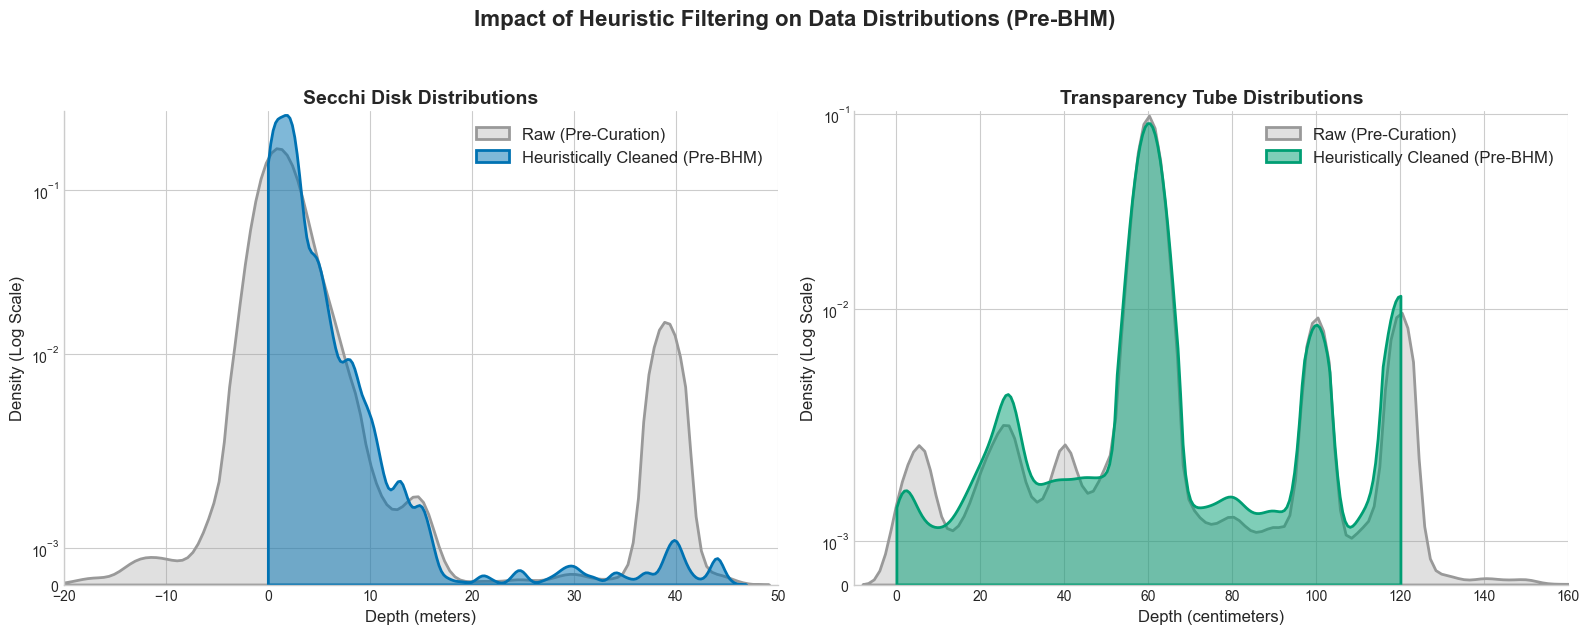

In [4]:
# =============================================================================
# 4. VISUALIZING THE CURATED DATA
# =============================================================================

# Save high resolution plot image locally
save_plot = True

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Set colors
color_raw = '#999999'          # Grey
color_disk_curated = '#0072B2' # Blue
color_tube_curated = '#009E73' # Bluish Green

# --- Secchi Disk Overlay ---
disk_raw = curated_disk['transparency_disk_image_disappearance_m'].dropna()
disk_clean = curated_disk[curated_disk['passed_heuristics']]['transparency_disk_image_disappearance_m'].dropna()

# Disable clipping to expose negative typos and extreme outliers
sns.kdeplot(data=disk_raw, ax=axes[0], color=color_raw, fill=True, alpha=0.3,
            linewidth=2, label='Raw (Pre-Curation)')

# Clip at 0 to prevent visualization artifacts; curated data contains no negative values
sns.kdeplot(data=disk_clean, ax=axes[0], color=color_disk_curated, fill=True, alpha=0.5,
            linewidth=2, label='Heuristically Cleaned (Pre-BHM)', clip=(0, None))

axes[0].set_title('Secchi Disk Distributions', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Depth (meters)', fontsize=12)
axes[0].set_ylabel('Density (Log Scale)', fontsize=12)
axes[0].legend(fontsize=12)

# Restrict axis limits to the structurally relevant density, excluding near-zero outliers.
axes[0].set_xlim(-20, 50)
axes[0].set_yscale('symlog', linthresh=0.005)

# --- Transparency Tube Overlay ---
tube_raw = curated_tube['tube_image_disappearance_cm'].dropna()
tube_clean = curated_tube[curated_tube['passed_heuristics']]['tube_image_disappearance_cm'].dropna()

# Disable clipping to expose negative typos and extreme outliers
sns.kdeplot(data=tube_raw, ax=axes[1], color=color_raw, fill=True, alpha=0.3,
            linewidth=2, label='Raw (Pre-Curation)')

# Clip at 0 and 120 to prevent visualization artifacts; curated data contains no negative or >120cm values.
sns.kdeplot(data=tube_clean, ax=axes[1], color=color_tube_curated, fill=True, alpha=0.5,
            linewidth=2, label='Heuristically Cleaned (Pre-BHM)', clip=(0, 120))

axes[1].set_title('Transparency Tube Distributions', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Depth (centimeters)', fontsize=12)
axes[1].set_ylabel('Density (Log Scale)', fontsize=12)
axes[1].legend(fontsize=12)

# Restrict axis limits to the structurally relevant density, excluding near-zero outliers.
axes[1].set_xlim(-10, 160)
axes[1].set_yscale('symlog', linthresh=0.005)

# Remove top and right spines
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Impact of Heuristic Filtering on Data Distributions (Pre-BHM)", fontsize=16, y=1.05, fontweight='bold')
plt.tight_layout()

if save_plot:
    os.makedirs('output/figures/00_quickstart_demo', exist_ok=True)
    fig_path = 'output/figures/00_quickstart_demo/kde_plot.png'
    plt.savefig(fig_path, bbox_inches='tight', dpi=300)
    print(f"\n✅ Quickstart plot saved to: {fig_path}\n")

plt.show()


In [5]:
# =============================================================================
# 5. BAYESIAN POSTERIOR PREDICTIVE ESTIMATION (SUBSET)
# =============================================================================

print("Running Bayesian models on a 500-sample subset to generate Posterior Predictive traces...")

# Take a small random sample of records that passed heuristics to speed up notebook execution
sample_size = 500
disk_subset = curated_disk[curated_disk['passed_heuristics']].sample(min(sample_size, curated_disk['passed_heuristics'].sum()), random_state=42)
tube_subset = curated_tube[curated_tube['passed_heuristics']].sample(min(sample_size, curated_tube['passed_heuristics'].sum()), random_state=42)

disk_model = BayesianDiskModel(config)
# Fast sampling params for demo purposes
disk_model.draws = 500
disk_model.tune = 500
disk_model.chains = 4
print(" -> Running Secchi Disk model...")
# Drop PII columns from notebook display
disk_model.evaluate(disk_subset, window_years=10).drop(columns=["userid", "usid"], errors="ignore")

tube_model = BayesianTubeModel(config)
tube_model.draws = 500
tube_model.tune = 500
tube_model.chains = 4
print(" -> Running Transparency Tube model...")
# Drop PII columns from notebook display
tube_model.evaluate(tube_subset, window_years=10).drop(columns=["userid", "usid"], errors="ignore")


Running Bayesian models on a 500-sample subset to generate Posterior Predictive traces...
 -> Running Secchi Disk model...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_mu, global_sigma, water_source_offset, water_source_sigma, site_offset, obs_sigma]


Output()

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 4 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


 -> Running Transparency Tube model...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_mu, global_sigma, water_source_offset, water_source_sigma, site_offset, obs_sigma]


Output()

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 4 seconds.


,organization_id,org_name,site_id,site_name,latitude,longitude,elevation,measured_on,measured_at,comments,...,distance_from_water_source,water_detected,tube_len_algo_site,tube_len_algo_country,tube_len_mle_site,tube_len_mle_country,passed_heuristics,is_censored,is_true_error,is_statistical_outlier
81144,47845373.0,Shree Swaminnarayan Academy,376598,Likoni Tumaini,-4.083530,39.668050,8.3,2025-02-03,2025-02-03T10:04:00,NaN,...,gee,True,120.0,NaN,120.0,NaN,True,False,False,True
17437,50044562.0,The first Arqah Secondary school Al-riyadh,148835,Noura Al-Hajri,24.690306,46.602502,656.0,2019-03-02,2019-03-02T11:00:00,NaN,...,none,False,60.0,NaN,60.0,NaN,True,True,False,None
12094,325404.0,The 9th Secondary Girls School at Al-Kharj,11969,The 9th secondary school at al-kharj,24.165141,47.330755,700.0,2018-10-04,2018-10-04T08:34:00,NaN,...,none,False,60.0,NaN,60.0,NaN,True,True,False,None
61823,2849736.0,The 2nd Secondary Girls School at Al-Mubarraz,13069,The 2nd Secondary Girls School at AL Mobraz:SW...,25.413300,49.562000,182.5,2023-02-21,2023-02-21T09:00:00,NaN,...,none,False,60.0,NaN,60.0,NaN,True,True,False,None
10556,31943260.0,The 19th Secondary Girls School at Al-Madinah ...,102338,Orgwan 👑🧜‍♀️,24.264980,39.402140,864.6,2018-07-01,2018-07-01T08:00:00,NaN,...,gee,True,60.0,NaN,120.0,NaN,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42447,15693220.0,"OŠ Ivana Filipovića, Osijek",45748,Drava,45.566967,18.665208,80.0,2021-04-21,2021-04-21T05:00:00,NaN,...,none,False,100.0,NaN,100.0,NaN,True,True,False,None
21048,50044562.0,The first Arqah Secondary school Al-riyadh,148822,Sadeem Al-Budairi,24.690306,46.602502,656.0,2019-07-13,2019-07-13T11:00:00,NaN,...,none,False,60.0,NaN,60.0,NaN,True,True,False,None
11168,94072.0,Tartu Kristjan Jaak Petersoni Gümnaasium,140720,Jõulumäe (kraav),58.224440,24.518060,13.0,2018-08-14,2018-08-14T08:00:00,NaN,...,none,False,120.0,NaN,120.0,NaN,True,False,False,True
76416,49096986.0,TCWA,361999,Northkill Creek above MollHead Ck Confluence,40.489927,-76.123278,141.0,2024-09-04,2024-09-04T16:00:00,NaN,...,none,False,120.0,NaN,120.0,NaN,True,False,False,False



✅ PPC plot saved to: output/figures/00_quickstart_demo/ppc_plot_manual.png



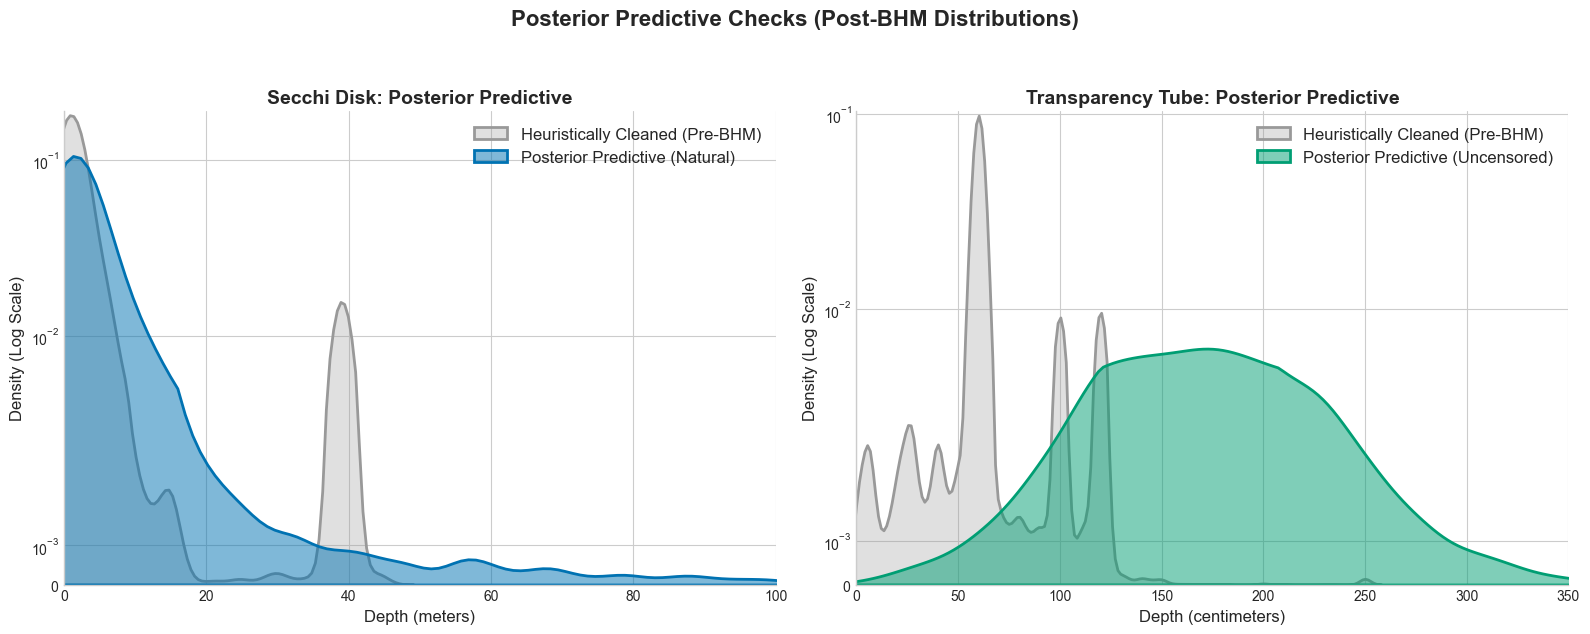


✅ Quickstart demonstration successful!


In [6]:
# =============================================================================
# 6. POSTERIOR PREDICTIVE CHECKS
# =============================================================================

# Save high resolution plot image locally
save_plot = True

# `sample_posterior_predictive` doesn't support our `pm.Potential` censored likelihoods.
# We manually sample the posterior trace to show the true natural distribution.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Set colors
color_raw = '#999999'          # Grey
color_disk_ppc = '#0072B2'     # Blue
color_tube_ppc = '#009E73'     # Bluish Green

# --- Disk PPC (Log-Normal) ---
if disk_model.trace is not None:
    post = disk_model.trace.posterior
    
    # Flatten chain and draw dimensions: mu -> (samples, sites), sigma -> (samples,)
    mu_samples = post["site_mu"].values.reshape(-1, post["site_mu"].shape[-1])
    sigma_samples = post["obs_sigma"].values.flatten()
    num_post_samples = len(sigma_samples)
    
    # Generate 5,000 random observations across random posterior samples and random sites
    idx_post = np.random.choice(num_post_samples, size=5000, replace=True)
    idx_site = np.random.choice(mu_samples.shape[1], size=5000, replace=True)
    
    selected_mu = mu_samples[idx_post, idx_site]
    selected_sigma = sigma_samples[idx_post]
    
    sim_disk = lognorm.rvs(s=selected_sigma, scale=np.exp(selected_mu))
    
    # Filter extreme un-converged outliers so KDE bandwidth calculation doesn't break
    sim_disk = sim_disk[sim_disk < 200]
    
    sns.kdeplot(curated_disk['transparency_disk_image_disappearance_m'].dropna(),
                ax=axes[0], color=color_raw, fill=True, alpha=0.3,
                linewidth=2, label="Heuristically Cleaned (Pre-BHM)")
    sns.kdeplot(sim_disk, ax=axes[0], color=color_disk_ppc, fill=True, alpha=0.5,
                linewidth=2, label="Posterior Predictive (Natural)")
    
    axes[0].set_title("Secchi Disk: Posterior Predictive", fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Depth (meters)', fontsize=12)
    axes[0].set_ylabel('Density (Log Scale)', fontsize=12)
    axes[0].set_xlim(0, 100)
    axes[0].set_yscale('symlog', linthresh=0.005)
    axes[0].legend(fontsize=12)
else:
    axes[0].text(0.5, 0.5, "Disk trace not available", ha='center')

# --- Tube PPC (Normal / Truncated) ---
if tube_model.trace is not None:
    post = tube_model.trace.posterior
    
    mu_samples = post["site_mu"].values.reshape(-1, post["site_mu"].shape[-1])
    sigma_samples = post["obs_sigma"].values.flatten()
    num_post_samples = len(sigma_samples)
    
    idx_post = np.random.choice(num_post_samples, size=5000, replace=True)
    idx_site = np.random.choice(mu_samples.shape[1], size=5000, replace=True)
    
    selected_mu = mu_samples[idx_post, idx_site]
    selected_sigma = sigma_samples[idx_post]
    
    # Sample from the underlying Normal distribution to show the true estimated water clarity,
    # accounting for the tube's physical truncation limit.
    sim_tube = np.random.normal(loc=selected_mu, scale=selected_sigma)
    # Clip at 0 since transparency can't be negative
    sim_tube = sim_tube[sim_tube > 0]
    # Filter extreme un-converged outliers so KDE bandwidth calculation doesn't break
    sim_tube = sim_tube[sim_tube < 500]
    
    sns.kdeplot(curated_tube['tube_image_disappearance_cm'].dropna(),
                ax=axes[1], color=color_raw, fill=True, alpha=0.3,
                linewidth=2, label="Heuristically Cleaned (Pre-BHM)")
    sns.kdeplot(sim_tube, ax=axes[1], color=color_tube_ppc, fill=True, alpha=0.5,
                linewidth=2, label="Posterior Predictive (Uncensored)")
    
    axes[1].set_title("Transparency Tube: Posterior Predictive", fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Depth (centimeters)', fontsize=12)
    axes[1].set_ylabel('Density (Log Scale)', fontsize=12)
    axes[1].set_xlim(0, 350)
    axes[1].set_yscale('symlog', linthresh=0.005)
    axes[1].legend(fontsize=12)
else:
    axes[1].text(0.5, 0.5, "Tube trace not available", ha='center')

# Remove top and right spines
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Posterior Predictive Checks (Post-BHM Distributions)", fontsize=16, y=1.05, fontweight='bold')
plt.tight_layout()

if save_plot:
    fig_path_ppc = 'output/figures/00_quickstart_demo/ppc_plot_manual.png'
    plt.savefig(fig_path_ppc, bbox_inches='tight', dpi=300)
    print(f"\n✅ PPC plot saved to: {fig_path_ppc}\n")

plt.show()

print("\n✅ Quickstart demonstration successful!")
